<a href="https://colab.research.google.com/github/CarlosAltamiranoR/recommender_system/blob/rs_2024/ModeloKeras_Ignacio_28_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cargar el archivo datos_movies.csv
movies_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movies.csv')

# Cargar el archivo datos_movies_list.csv
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/resultados.csv')


In [ ]:
# Mostrar las primeras 5 filas como muestra
movies_df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",10-12-2009,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",19-05-2007,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",26-10-2015,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",16-07-2012,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",07-03-2012,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [ ]:
# Mostrar las primeras 5 filas como muestra
data.head()

,ID_Pelicula,ID_Lista
0,285,2457830
1,19995,41864669
2,19995,43478626
3,285,18477098
4,19995,206047


# Limpieza

In [ ]:
# Calcular el número de películas en cada lista
list_sizes = data.groupby('ID_Lista').size()

# Crear un DataFrame temporal con índices como categorías
list_sizes_df = list_sizes.reset_index()
list_sizes_df.columns = ['item', 'size']


# Mostrar estadísticas descriptivas
print("Estadísticas de tamaños de listas:")
print(list_sizes.describe())

Estadísticas de tamaños de listas:
count    51820.000000
mean        10.198244
std         62.458949
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       3853.000000
dtype: float64


In [ ]:
list_sizes_df

,item,size
0,13,24
1,16,1
2,456,1
3,524,1
4,526,1
...,...,...
51815,54060383,1
51816,54060413,1
51817,54061847,1
51818,54079725,1


## mostrar graficamente distribución

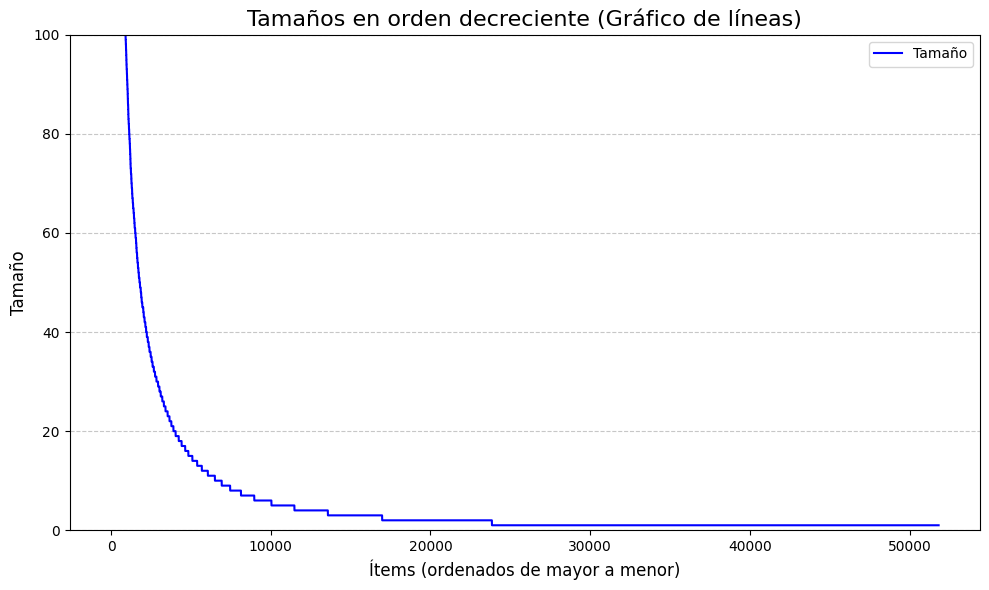

In [ ]:
# Ordenar por tamaño descendente
list_sizes_sorted = list_sizes_df.sort_values(by='size', ascending=False)

sizes = list_sizes_sorted['size'].tolist()

# Crear el gráfico de líneas
plt.figure(figsize=(10, 6))
plt.plot(sizes, linestyle='-', color='b', label='Tamaño')


# Títulos y etiquetas
plt.title('Tamaños en orden decreciente (Gráfico de líneas)', fontsize=16)
plt.xlabel('Ítems (ordenados de mayor a menor)', fontsize=12)
plt.ylabel('Tamaño', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0,100)

plt.tight_layout()
plt.show()

In [ ]:
# Definir un umbral para listas muy cortas (por ejemplo, menos de 2 películas)
short_list_threshold = 10

# Filtrar listas muy cortas
short_lists = list_sizes[list_sizes < short_list_threshold]

print(f"Número de listas con menos de {short_list_threshold} películas: {len(short_lists)}")
print("IDs de listas muy cortas:")
print(short_lists.index.tolist())

Número de listas con menos de 10 películas: 44892
IDs de listas muy cortas:
[16, 456, 524, 526, 533, 615, 663, 1002, 1189, 1264, 1323, 1425, 2108, 2118, 2527, 2629, 3346, 3347, 3352, 3803, 4260, 4333, 4352, 4402, 4416, 4575, 4614, 4812, 4963, 4978, 5044, 5166, 5797, 5872, 6374, 6404, 6428, 6654, 7652, 7722, 7732, 7943, 7946, 8061, 8275, 8446, 8472, 8592, 8899, 8922, 8995, 9128, 9136, 9262, 9312, 9338, 9406, 9954, 10258, 10347, 10589, 10596, 10720, 10918, 11064, 11116, 11123, 11208, 11248, 11288, 11847, 12041, 12044, 12048, 12129, 12411, 12553, 12919, 13344, 13518, 13621, 13884, 13937, 13967, 14052, 14055, 14179, 15117, 15430, 15681, 16095, 16169, 16336, 16403, 16469, 16661, 16875, 16888, 17323, 17637, 17814, 17881, 18180, 18328, 18469, 18498, 18502, 18561, 18988, 19385, 19565, 19618, 19649, 19676, 19683, 19904, 19932, 19940, 19952, 20009, 20065, 20087, 20090, 20118, 20125, 20162, 20266, 20592, 20921, 20963, 21085, 21130, 21289, 21337, 21347, 21399, 21530, 21606, 21684, 21809, 21819, 21

In [ ]:
# Filtrar las listas que cumplen con el tamaño mínimo
valid_list_ids = list_sizes[list_sizes >= short_list_threshold].index
data = data[data['ID_Lista'].isin(valid_list_ids)]

In [ ]:
# Contar cuántas veces aparece cada película en las listas
movie_counts = data['ID_Pelicula'].value_counts()

# Mostrar estadísticas descriptivas
print("Estadísticas de frecuencias de películas:")
print(movie_counts.describe())

Estadísticas de frecuencias de películas:
count    4523.000000
mean       96.956445
std        26.546415
min         1.000000
25%        92.000000
50%       107.000000
75%       114.000000
max       120.000000
Name: count, dtype: float64


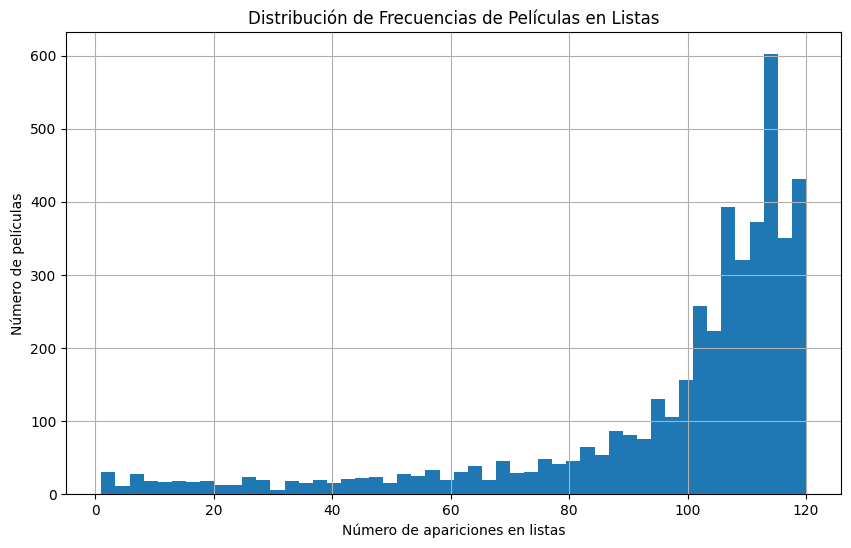

In [ ]:
plt.figure(figsize=(10,6))
movie_counts.hist(bins=50)
plt.title('Distribución de Frecuencias de Películas en Listas')
plt.xlabel('Número de apariciones en listas')
plt.ylabel('Número de películas')
plt.show()

In [ ]:
# Definir un umbral para películas muy frecuentes (por ejemplo, aparecen en más del 5% de las listas)
frequency_threshold = data['ID_Lista'].nunique() * 0.05

frequent_movies = movie_counts[movie_counts > frequency_threshold]

print(f"Número de películas que aparecen en más del 5% de las listas: {len(frequent_movies)}")
print("IDs de películas muy frecuentes:")
print(frequent_movies.index.tolist())

Número de películas que aparecen en más del 5% de las listas: 0
IDs de películas muy frecuentes:
[]


ninguna película aparece en más del 5% de las listas. Es decir, no hay películas que sean extremadamente frecuentes en el conjunto de datos.

**Implicaciones**: Dado que no hay películas que aparezcan con tanta frecuencia, el problema de que el modelo recomiende siempre las mismas películas no se debe a que ciertas películas estén sobre-representadas en los datos.

In [ ]:
# Contar la frecuencia de cada película
movie_counts = data['ID_Pelicula'].value_counts()
print(movie_counts.head(4000))  # Ver las 10 películas más frecuentes


ID_Pelicula
218       120
33        120
15121     120
2787      120
10331     120
         ... 
220490     63
41830      63
318040     63
90414      63
158895     63
Name: count, Length: 4000, dtype: int64


# Modelo IA

In [ ]:
# Obtener el conjunto de IDs de películas presentes en datos_movies_list.csv
movie_ids_in_list = set(data['ID_Pelicula'].astype(str))

# Filtrar movies_df para que solo contenga películas en movie_ids_in_list
movies_df = movies_df[movies_df['id'].astype(str).isin(movie_ids_in_list)].reset_index(drop=True)


In [ ]:
# Convertir IDs a string para consistencia
data['ID_Pelicula'] = data['ID_Pelicula'].astype(str)
data['ID_Lista'] = data['ID_Lista'].astype(str)

# Obtener el conjunto de todos los IDs de películas
all_movie_ids = set(data['ID_Pelicula'])

# Crear un diccionario que mapea ID_Lista a un conjunto de IDs de películas
list_to_movies = data.groupby('ID_Lista')['ID_Pelicula'].apply(set).to_dict()


In [ ]:
# Crear un diccionario que mapea ID_Pelicula a un índice único
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(sorted(all_movie_ids))}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

# Número total de películas
num_movies = len(movie_id_to_index)


In [ ]:
# Obtener todos los IDs de listas
all_list_ids = list(list_to_movies.keys())

# Dividir en entrenamiento y prueba
train_list_ids, test_list_ids = train_test_split(all_list_ids, test_size=0.5, random_state=42)


In [ ]:
for id in list_to_movies['7633979']:
   print(movies_df[movies_df['id'].astype(str) == id]['title'].values[0])

Blast from the Past
Blonde Ambition
Dick
Clockwatchers
St. Trinian's
I Love You, Don't Touch Me!
Home Fries
Simply Irresistible
Coyote Ugly
D.E.B.S.
Slums of Beverly Hills
Woo
Tank Girl
Little Voice
Heavenly Creatures
Glitter
Sleepover
Beautiful Creatures
Get Over It
The Sweetest Thing
Anywhere But Here
Raise Your Voice
Psycho Beach Party
Drop Dead Gorgeous
High Heels and Low Lifes
Connie and Carla
Girl 6
Josie and the Pussycats
Birthday Girl
From Justin to Kelly
Riding in Cars with Boys
Raising Helen
On the Line
Brave New Girl
The Perez Family
Blue Car
Set It Off
16 to Life
The Incredibly True Adventure of Two Girls In Love
Party Monster
Hav Plenty
How to Deal
Bandits
Mirror Mirror
Return to Me


In [ ]:
def create_dataset(list_ids, iter_per_list=10):
    X = []
    Y = []
    for list_id in list_ids:
      for i in range(iter_per_list):
        movies_in_list = list(list_to_movies[list_id])
        num_movies_in_list = len(movies_in_list)

        if num_movies_in_list < 10:
            continue  # Saltar listas con menos de 2 películas

        # Seleccionar aleatoriamente entre 2 y 5 películas para x
        num_movies_in_x = num_movies_in_list//2
        movies_in_x = random.sample(movies_in_list, num_movies_in_x)

        # Crear vector x
        x = np.zeros(num_movies)
        for movie_id in movies_in_x:
            idx = movie_id_to_index[str(movie_id)]
            x[idx] = 1

        # Crear vector y
        y = np.zeros(num_movies)
        for movie_id in movies_in_list:
             idx = movie_id_to_index[str(movie_id)]
             y[idx] = 1

        # Agregar a los conjuntos de datos
        X.append(x)
        Y.append(y)

    return np.array(X), np.array(Y)


In [ ]:
X_train, Y_train = create_dataset(train_list_ids)
X_test, Y_test = create_dataset(test_list_ids)
X_train.shape, Y_train.shape

((34640, 4523), (34640, 4523))

In [ ]:
np.nonzero(X_train[15]),np.nonzero(Y_train[15])

((array([  61,  156,  376,  385,  438,  459,  485,  615,  650,  839,  870,
          936, 1462, 1937, 2113, 2254, 2367, 2481, 2859, 2974, 3080, 3106,
         3379, 3400, 3502, 3543, 3659, 3697, 3858, 3891, 4050, 4109, 4110,
         4326, 4436, 4499, 4522]),),
 (array([  61,   85,  155,  156,  161,  274,  299,  375,  376,  385,  399,
          438,  459,  472,  485,  615,  644,  650,  811,  839,  870,  936,
         1209, 1300, 1462, 1687, 1767, 1937, 2087, 2113, 2254, 2257, 2367,
         2409, 2481, 2507, 2510, 2609, 2662, 2757, 2859, 2974, 3080, 3106,
         3155, 3281, 3379, 3389, 3400, 3442, 3486, 3502, 3519, 3543, 3603,
         3608, 3659, 3697, 3719, 3851, 3858, 3891, 4050, 4098, 4103, 4109,
         4110, 4312, 4325, 4326, 4422, 4436, 4447, 4499, 4522]),))

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def binary_focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        pt = tf.where(K.equal(y_true, 1), y_pred, 1 - y_pred)
        loss = -K.mean(alpha * K.pow(1. - pt, gamma) * K.log(pt))
        return loss
    return focal_loss_fixed




Definimos métricas personalizadas

In [ ]:
def custom_precision(y_true, y_pred):
    y_pred_binary = tf.cast(tf.greater(y_pred, 0.1), tf.float32)
    true_positives = tf.reduce_sum(y_true * y_pred_binary)
    predicted_positives = tf.reduce_sum(y_pred_binary)
    precision = true_positives / (predicted_positives + tf.keras.backend.epsilon())
    return precision

def custom_recall(y_true, y_pred):
    y_pred_binary = tf.cast(tf.greater(y_pred, 0.1), tf.float32)
    true_positives = tf.reduce_sum(y_true * y_pred_binary)
    possible_positives = tf.reduce_sum(y_true)
    recall = true_positives / (possible_positives + tf.keras.backend.epsilon())
    return recall

In [ ]:
# @title
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.callbacks import EarlyStopping
#binary cross entropy
from tensorflow.keras.losses import binary_crossentropy

# Definir el modelo
model = Sequential()
model.add(Input(shape=(num_movies,)))  # Añadimos una capa de entrada explícita
model.add(Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.3))
model.add(Dense(num_movies, activation='sigmoid'))  # Usamos sigmoid para salida multi-etiqueta

# Compilar el modelo con Binary Focal Loss
#model.compile(optimizer='adam', loss=binary_focal_loss(gamma=2., alpha=.25), metrics=['accuracy'])

# Compilar el modelo con Binary Focal Loss con métricas personalizadas
model.compile(optimizer='adam',loss=binary_focal_loss(gamma=2., alpha=.25), metrics=['accuracy', custom_precision, custom_recall])

#model.compile(optimizer='adam',loss=binary_crossentropy, metrics=['accuracy', custom_precision, custom_recall])


# Entrenar el modelo
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train, Y_train, epochs=5, batch_size=64, validation_split=0.1, callbacks=[early_stopping])


# Generar predicciones en el conjunto de prueba
Y_pred_prob = model.predict(X_test)
threshold = 0.1  # Ajustar este valor según sea necesario
Y_pred = (Y_pred_prob > threshold).astype(int)



Epoch 1/5
488/488 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 4.3560e-04 - custom_precision: 0.0164 - custom_recall: 0.8988 - loss: 0.0138 - val_accuracy: 0.0000e+00 - val_custom_precision: 0.0210 - val_custom_recall: 0.9402 - val_loss: 0.0043
Epoch 2/5
488/488 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.0024 - custom_precision: 0.0229 - custom_recall: 0.9579 - loss: 0.0041 - val_accuracy: 0.0144 - val_custom_precision: 0.0295 - val_custom_recall: 0.9624 - val_loss: 0.0036
Epoch 3/5
488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0062 - custom_precision: 0.0321 - custom_recall: 0.9699 - loss: 0.0034 - val_accuracy: 0.0046 - val_custom_precision: 0.0363 - val_custom_recall: 0.9612 - val_loss: 0.0034
Epoch 4/5
488/488 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0095 - custom_precision: 0.0390 - custom_recall: 0.9753 - loss: 0.0031 - val_accuracy: 0.0144 - val_custom_precision: 0.0406 - val_custom_recall: 0.9628 - val_loss: 0.0032
Epoch 5/5
488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 4

In [ ]:
X_train, Y_train = create_dataset(train_list_ids)
model.fit(X_train, Y_train, epochs=5, batch_size=64, validation_split=0.1, callbacks=[early_stopping])

Parámetros:
gamma: Controla el enfoque en las muestras difíciles. Un valor más alto incrementa el enfoque.
alpha: Equilibra la importancia entre clases positivas y negativas.

In [ ]:
import sys
import os
import contextlib

@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

def get_recommendations(input_movie_ids, top_n=5):
    # Crear vector x con una sola película
    x = np.zeros(num_movies)
    idxs = set()
    #if input_movie_ids is list
    if isinstance(input_movie_ids, list):
        for movie_id in input_movie_ids:
            idx = movie_id_to_index[str(movie_id)]
            idxs.add(idx)

            x[idx] = 1
    else:
        idx = movie_id_to_index[str(input_movie_ids)]
        x[idx] = 1

    # Suprimir la salida estándar durante la predicción
    with suppress_stdout():
        y_pred_prob = model.predict(np.array([x]))[0]

    # Obtener los índices de las top_n predicciones
    recommended_indices = np.argsort(y_pred_prob)[::-1]

    # Filtrar películas que no sean la película de entrada
    recommended_indices = [i for i in recommended_indices if i != idx and i not in idxs]

    # Obtener los IDs de las películas recomendadas
    recommended_movie_ids = [index_to_movie_id[i] for i in recommended_indices[:top_n]]

    # Obtener los nombres de las películas recomendadas
    recommended_movies = movies_df[movies_df['id'].astype(str).isin(recommended_movie_ids)]

    return recommended_movies[['id', 'title']]




In [ ]:
from collections import Counter

# Paso 1: Crear una lista con todas las películas (descomponiendo los sets)
all_movies = [movie for movies_set in list_to_movies.values() for movie in movies_set]

# Paso 2: Contar las apariciones de cada película
movie_counts = Counter(all_movies)

# Paso 3: Ordenar por mayor a menor aparición
sorted_movie_counts = sorted(movie_counts.items(), key=lambda x: x[1], reverse=True)

# Resultado
for movie, count in sorted_movie_counts [:10]:
    print(f"{movie}: {count} veces")

In [ ]:
list_to_movies['7633979']

In [ ]:
get_recommendations(['10034','10050'], 10)

In [ ]:
def get_movie_names(movie_ids):
    return movies_df[movies_df['id'].astype(str).isin(movie_ids)]['title'].tolist()

In [ ]:
# Evaluar las recomendaciones
results = []

# Limitar el número de listas de prueba
max_test_lists = 100
test_list_ids_subset = random.sample(test_list_ids, min(max_test_lists, len(test_list_ids)))

for list_id in test_list_ids_subset:
    movies_in_list = list(list_to_movies[list_id])
    num_movies_in_list = len(movies_in_list)

    if num_movies_in_list < 10:
        print(1)
        continue  # Saltar listas con menos de 3 películas

    # Seleccionar una película al azar de la lista
    input_movie_id = random.choice(movies_in_list)

    # Obtener recomendaciones
    recommended_movies = get_recommendations(input_movie_id, top_n=20)

    # Obtener los IDs y nombres de las películas recomendadas
    recommended_movie_ids = set(recommended_movies['id'].astype(str))
    recommended_movie_names = recommended_movies['title'].tolist()

    # Películas correctas (que están en la misma lista)
    actual_movie_ids = set(movies_in_list)
    #actual_movie_ids.discard(input_movie_id)  # Excluir la película de entrada

    # Contar cuántas recomendaciones están en la misma lista
    correct_recommendations = recommended_movie_ids.intersection(actual_movie_ids)
    num_correct = len(correct_recommendations)
    correct_recommendation_names = get_movie_names(correct_recommendations)

    # Porcentaje de acierto
    possible_correct = min(20, len(actual_movie_ids))
    hit_percentage = num_correct / possible_correct if possible_correct > 0 else 0

    # Guardar resultados
    results.append({
        'ID_Lista': list_id,
        'Película_Entrada_ID': input_movie_id,
        'Película_Entrada_Nombre': movies_df[movies_df['id'].astype(str) == input_movie_id]['title'].values[0],
        'Recomendaciones_IDs': list(recommended_movie_ids),
        'Recomendaciones_Nombres': recommended_movie_names,
        'Películas_Correctas_IDs': list(actual_movie_ids),
        'Películas_Correctas_Nombres': get_movie_names(actual_movie_ids),
        'Aciertos_Nombres': correct_recommendation_names,
        'Aciertos': num_correct,
        'Posibles_Aciertos': possible_correct,
        'Porcentaje_Acierto': hit_percentage
    })


# Analizar resultados

In [ ]:
results_df = pd.DataFrame(results)

# Calcular el porcentaje medio de aciertos
mean_hit_percentage = results_df['Porcentaje_Acierto'].mean()
print(f"Porcentaje medio de aciertos: {mean_hit_percentage:.2%}")

# Mostrar algunos resultados
results_df[['Película_Entrada_Nombre', 'Recomendaciones_Nombres', 'Aciertos_Nombres', 'Porcentaje_Acierto']]



# analisis detallado

In [ ]:
# Proporción de etiquetas positivas en Y_train
positive_ratio = np.sum(Y_train) / (Y_train.shape[0] * Y_train.shape[1])
print(f"Proporción de etiquetas positivas en Y_train: {positive_ratio:.6f}")

# Proporción de etiquetas positivas en Y_test
positive_ratio_test = np.sum(Y_test) / (Y_test.shape[0] * Y_test.shape[1])
print(f"Proporción de etiquetas positivas en Y_test: {positive_ratio_test:.6f}")


Interpretación:

Si la proporción es muy baja (por ejemplo, menos del 0.1%), indica que las etiquetas son extremadamente esparsas.
Esto dificulta que el modelo aprenda, ya que hay muy pocas muestras positivas.
Solución:

Cambiar la función de pérdida a Kullback-Leibler Divergence ('kullback_leibler_divergence') o Binary Focal Loss que manejan mejor la esparsidad.
Ajustar los pesos de clase para penalizar más los errores en clases minoritarias.